### Anomaly Detection in Energy Consumption

Anomaly detection is used to identify unusual spikes or drops in energy consumption.

Such anomalies may indicate faults, abnormal usage patterns, or system inefficiencies.

### 1. Import Libraries

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

### 2. Load Processed Dataset

In [20]:
energy = pd.read_csv(
    '../data/processed/energy_hourly.csv',
    index_col=0,
    parse_dates=True
)

energy.head()

,Global_active_power
datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


### 3. Anomaly Detection Strategy

Anomaly detection is used to identify unusual spikes or drops in energy consumption.

A rolling statistical approach is used:
- Rolling Mean → captures local trend
- Rolling Standard Deviation → captures variability

Data points that fall beyond a defined threshold (mean ± 3 × standard deviation) are considered anomalies.

### 4. Compute Rolling Statistics

In [21]:
# Rolling mean and std
rolling_mean = energy.rolling(window=24).mean()
rolling_std = energy.rolling(window=24).std()

### 5. Detect Anomalies

In [22]:
# Define anomaly threshold
threshold = 3

anomalies = energy[
    (energy > rolling_mean + threshold * rolling_std) |
    (energy < rolling_mean - threshold * rolling_std)
]

### 6. Visualization of Anomalies

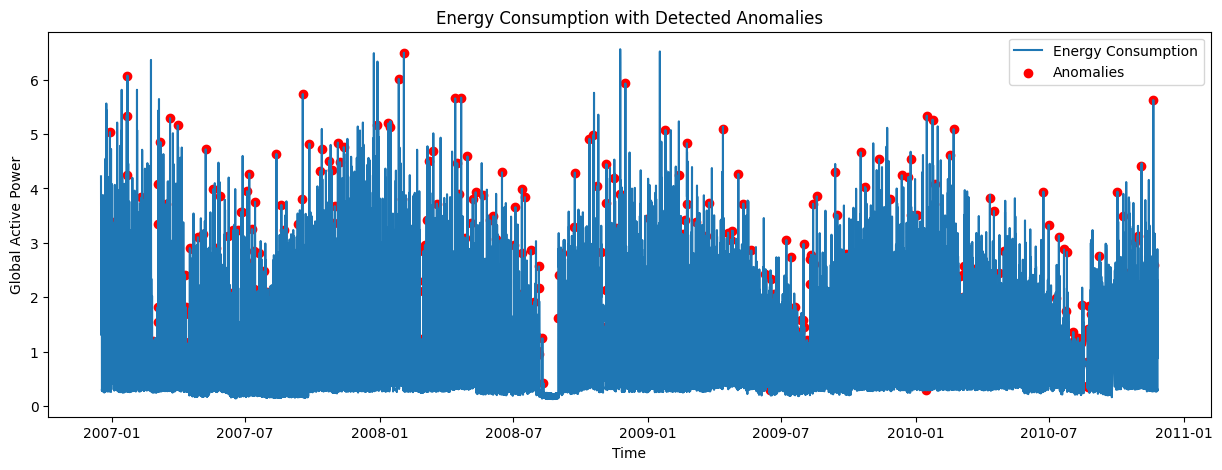

In [23]:
plt.figure(figsize=(15,5))

plt.plot(energy, label='Energy Consumption')

plt.scatter(
    anomalies.index,
    anomalies,
    color='red',
    label='Anomalies'
)

plt.title('Energy Consumption with Detected Anomalies')
plt.xlabel('Time')
plt.ylabel('Global Active Power')

plt.legend()
plt.show()

### 7. Interpretation

The highlighted points represent anomalies in energy consumption.

These anomalies indicate unusual deviations from normal consumption patterns.

Possible causes include:
- Sudden increase in appliance usage
- Faulty electrical devices
- External environmental factors

Detecting such anomalies is useful for monitoring energy efficiency and identifying potential issues in advance.

### 8. Key Observations

- Most data points follow a consistent pattern with daily seasonality.
- A small number of anomalies are detected, indicating rare abnormal events.
- The rolling statistical method provides a simple yet effective way to identify unusual behavior in time series data.

### 9. Number of Anomalies

In [24]:
print("Total anomalies detected:", len(anomalies))

Total anomalies detected: 34589
